In [1]:
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from sklearn.model_selection import train_test_split
from baskervillehall.baskervillehall_isolation_forest import BaskervillehallIsolationForest

2024-06-26 18:44:41.114707: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-06-26 18:44:41.160037: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-26 18:44:41.160072: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-26 18:44:41.161208: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-06-26 18:44:41.168456: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-06-26 18:44:41.169003: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [2]:
tf.get_logger().setLevel('ERROR')

# bert_model_name = 'small_bert/bert_en_uncased_L-4_H-512_A-8'
bert_model_name = 'small_bert/bert_en_uncased_L-2_H-128_A-2'
# bert_model_name = 'electra_base'

map_name_to_handle = {
    'bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/3',
    'bert_en_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_cased_L-12_H-768_A-12/3',
    'bert_multi_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_multi_cased_L-12_H-768_A-12/3',
    'small_bert/bert_en_uncased_L-2_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-2_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-2_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-2_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-4_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-4_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-4_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-6_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-6_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-6_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-6_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-8_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-8_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-8_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-8_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-10_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-10_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-10_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-10_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-12_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-12_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-12_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-768_A-12/1',
    'albert_en_base':
        'https://tfhub.dev/tensorflow/albert_en_base/2',
    'electra_small':
        'https://tfhub.dev/google/electra_small/2',
    'electra_base':
        'https://tfhub.dev/google/electra_base/2',
    'experts_pubmed':
        'https://tfhub.dev/google/experts/bert/pubmed/2',
    'experts_wiki_books':
        'https://tfhub.dev/google/experts/bert/wiki_books/2',
    'talking-heads_base':
        'https://tfhub.dev/tensorflow/talkheads_ggelu_bert_en_base/1',
}

map_model_to_preprocess = {
    'bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'bert_en_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_cased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'bert_multi_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_multi_cased_preprocess/3',
    'albert_en_base':
        'https://tfhub.dev/tensorflow/albert_en_preprocess/3',
    'electra_small':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'electra_base':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'experts_pubmed':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'experts_wiki_books':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'talking-heads_base':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
}

tfhub_handle_encoder = map_name_to_handle[bert_model_name]
tfhub_handle_preprocess = map_model_to_preprocess[bert_model_name]

print(f'BERT model selected           : {tfhub_handle_encoder}')
print(f'Preprocess model auto-selected: {tfhub_handle_preprocess}')

print('Loading...')
bert_preprocess_model = hub.KerasLayer(tfhub_handle_preprocess)

print('Processing...')
text_test = ['this is such an amazing movie!']
text_preprocessed = bert_preprocess_model(text_test)

print(f'Keys       : {list(text_preprocessed.keys())}')
print(f'Shape      : {text_preprocessed["input_word_ids"].shape}')
print(f'Word Ids   : {text_preprocessed["input_word_ids"][0, :12]}')
print(f'Input Mask : {text_preprocessed["input_mask"][0, :12]}')
print(f'Type Ids   : {text_preprocessed["input_type_ids"][0, :12]}')

bert_model = hub.KerasLayer(tfhub_handle_encoder)

bert_results = bert_model(text_preprocessed)

print(f'Loaded BERT: {tfhub_handle_encoder}')
print(f'Pooled Outputs Shape:{bert_results["pooled_output"].shape}')
print(f'Pooled Outputs Values:{bert_results["pooled_output"][0, :12]}')
print(f'Sequence Outputs Shape:{bert_results["sequence_output"].shape}')
print(f'Sequence Outputs Values:{bert_results["sequence_output"][0, :12]}')

BERT model selected           : https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-128_A-2/1
Preprocess model auto-selected: https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3
Loading...
Processing...
Keys       : ['input_mask', 'input_word_ids', 'input_type_ids']
Shape      : (1, 128)
Word Ids   : [ 101 2023 2003 2107 2019 6429 3185  999  102    0    0    0]
Input Mask : [1 1 1 1 1 1 1 1 1 0 0 0]
Type Ids   : [0 0 0 0 0 0 0 0 0 0 0 0]
Loaded BERT: https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-128_A-2/1
Pooled Outputs Shape:(1, 128)
Pooled Outputs Values:[-0.9999946   0.14341968 -0.9989779   0.9951449  -0.99974567  0.9131291
 -0.9961581  -0.97097486  0.09740014  0.01907066 -0.8488175  -0.09385542]
Sequence Outputs Shape:(1, 128, 128)
Sequence Outputs Values:[[-0.437236   -1.0138295  -2.3744745  ... -0.7589703  -2.0910308
  -0.2580995 ]
 [-1.3369716  -0.36880207  0.57868755 ... -2.1810157  -1.7530916
  -0.09555069]
 [-1.0607051  -0.30371016  0.34461278 

In [3]:
from kafka import KafkaConsumer, TopicPartition
import json
import numpy as np
from datetime import datetime, timedelta
import re

In [4]:
kafka_url = ['kafka9-0.kafka9-headless.default.svc.cluster.local:9093','kafka9-1.kafka9-headless.default.svc.cluster.local:9093','kafka9-2.kafka9-headless.default.svc.cluster.local:9093']
topic = 'BASKERVILLEHALL_4'

In [5]:
host = 'verafiles.org'
datetime_format = '%Y-%m-%d %H:%M:%S'

In [6]:
def is_bot_ua(ua):
    ua_lowercase = ua.lower()
    return 'bot' in ua_lowercase or 'spider' in ua_lowercase or 'crawl' in ua_lowercase

def is_human(session):
    return not BaskervillehallIsolationForest.is_bot_ua(session['ua'])

In [7]:
def read_sessions(host, datetime_format, max_size=3000, human=True):
    partitions = {
        'zhitomir.info': 1,
        'urban-pushkino.ru': 0,
        'dev.emawpb.org': 0,
        'palestinechronicle.com': 1,
        'equalit.ie': 0,
        'lexota.org': 0,
        'kavkaz-uzel.eu': 0,
        'amp.kavkaz-uzel.eu': 2,
        'indymedia.nl': 0,
        'btselem.org': 0,
        'verafiles.org': 1,
        'telegraf.in.ua': 2,
        'gubernia.com': 1
    }
    partition = partitions[host]
    consumer = KafkaConsumer(
        bootstrap_servers=kafka_url,
        group_id='pca'
    )
    print(f'Reading from kafka. Host = {host} ... partition = {partition}')
    num = 0
    sessions = []
    ips = []

    consumer.assign([TopicPartition(topic, partition)])
    consumer.seek_to_beginning()
    complete = False
    read = 0
    ts_now = datetime.now()
    while not complete:
        raw_messages = consumer.poll(timeout_ms=1000, max_records=5000)

        for topic_partition, messages in raw_messages.items():
            for message in messages:
                if message.value is None :
                    continue
                if message.key is None:
                    continue
                session = json.loads(message.value.decode("utf-8"))
                ts = datetime.strptime(session['start'], datetime_format)
                # print(ts, ts_now, (ts_now - ts).total_seconds(), 2 * 60 * 60)
                # break
                # if (ts_now - ts).total_seconds() > 3 * 60 * 60:
                #     continue

                # if read % 10000 == 0:
                #     print(ts)
                read += 1

                if message.key.decode("utf-8") != host:
                    continue
                if human:
                    if not is_human(session):
                        continue
                    if session['primary_session']:
                        continue
                else:
                    if is_human(session):
                        continue
                        
                # if session['duration'] > 60:
                #     continue
                sessions.append(session)
                ips.append(session['ip']) 
                num += 1
                if num % 100 == 0:
                    print(f'{num} sessions read', session['end'], message.timestamp)

                if num == max_size:
                    complete = True
                    break
            
    return sessions, ips

In [9]:
sessions, ips = read_sessions(
    host=host, 
    max_size=300,
    datetime_format=datetime_format,
    human=True
)
print('Done.')

Reading from kafka. Host = verafiles.org ... partition = 1
100 sessions read 2024-06-26 13:00:56 1719406858069
200 sessions read 2024-06-26 13:07:09 1719407230706
300 sessions read 2024-06-26 13:12:40 1719407562649
Done.


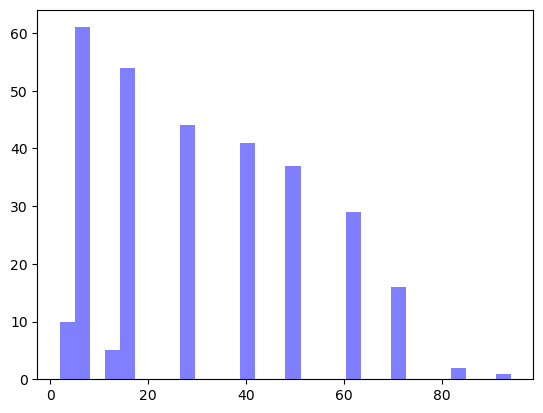

In [10]:
import matplotlib.pyplot as plt
n, bins, patches = plt.hist([len(s['requests']) for s in sessions], facecolor='blue', alpha=0.5, bins=30)
plt.rcParams["figure.figsize"] = (22,5)
plt.show()

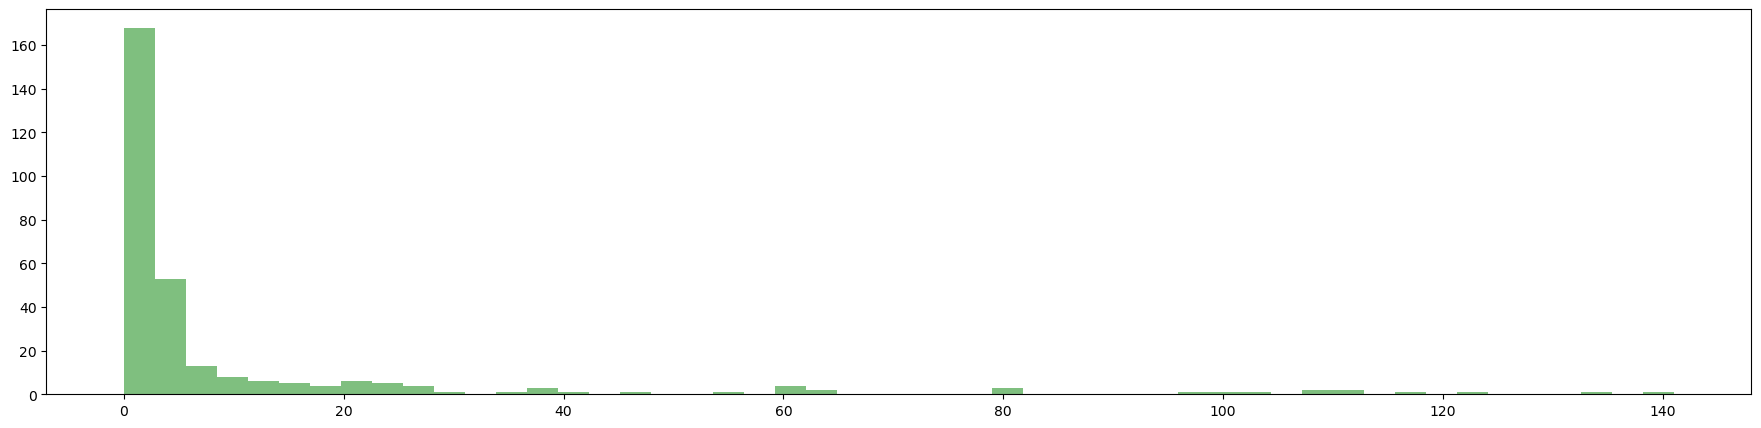

In [11]:
n, bins, patches = plt.hist([s['duration'] for s in sessions], facecolor='green', alpha=0.5, bins=50)
plt.rcParams["figure.figsize"] = (22,5)
plt.show()

In [12]:
num_primary = 0
for s in sessions:
    if s['primary_session'] == True:
        num_primary += 1
print(f'Number of primary sessions = {num_primary} - {num_primary*100.0/len(sessions)}%')

Number of primary sessions = 0 - 0.0%


In [13]:
import re
from urllib.parse import urlparse, unquote

def urls_to_text(urls, host):
    texts = []
    for url in urls:
        if url == '/':
            words = [host, 'home page']
        else:
            # Decode URL to convert %20, etc. into real characters
            url = unquote(url)
        
            # Parse the URL to isolate different parts
            parsed_url = urlparse(url)
        
            # Extract the subdomain, path, and query string
            # Assuming top-level domain and second-level domain are not 'real words'
            subdomain_path_query = parsed_url.netloc.split('.')[:-2] + parsed_url.path.split('/') + parsed_url.query.split('&')
        
            # Join these components into a single string, replacing delimiters with a space
            combined = ' '.join(subdomain_path_query).replace('-', ' ').replace('_', ' ')
        
            # Regular expression to extract words (alphanumeric characters)
            word_pattern = re.compile(r'\b[a-zA-Z0-9]+\b')
        
            # Find all words in the combined string
            words = word_pattern.findall(combined)
            if len(words) == 0:
                words = ['host']
        
        texts.append(' '.join([w for w in words if len(w) > 2]))
    return texts

# Example usage
print(urls_to_text(["/articles/vera-files-fact-check-katwiran-ng-palasyo-sa-hindi-pagsama-ng-anibersaryo-ng-people-power-bilang-holiday-nakaliligaw"], host))

print(urls_to_text(["/"], host))
print(urls_to_text(['/articles/103346'], host))

['articles vera files fact check katwiran palasyo hindi pagsama anibersaryo people power bilang holiday nakaliligaw']
['verafiles.org home page']
['articles 103346']


In [14]:
def texts_to_vec(texts):
    print('Tokenizing...')
    text_preprocessed = bert_preprocess_model(texts)
    print('Embedding...')
    bert_results = bert_model(text_preprocessed)
    return bert_results["pooled_output"]    
    
def urls_to_vec(urls, host):
    return texts_to_vec(urls_to_text(urls, host))

print(urls_to_vec(
    ["/articles/vera-files-fact-check-katwiran-ng-palasyo-sa-hindi-pagsama-ng-anibersaryo-ng-people-power-bilang-holiday-nakaliligaw"], host))

Tokenizing...
Embedding...
tf.Tensor(
[[-0.9999764   0.19326453 -0.86649436  0.8186717  -0.898907    0.6552071
  -0.6904768  -0.9877818   0.04541978  0.13958299  0.10461828  0.06614798
   0.03917221  0.7409936   0.93302655 -0.9707956   0.964541    0.10163551
   0.65973175 -0.651209    0.8601653  -0.01048797 -0.81353366 -0.88087094
  -0.99934834 -0.16712639 -0.9989296   0.9723801   0.90935767  0.04857476
  -0.04107029 -0.0612041  -0.9819613  -0.8888847   0.9917795   0.9786941
  -0.9978268  -0.065966    0.9653106  -0.6358589   0.950877    0.56321394
  -0.0772117  -0.16933256  0.80293787 -0.17133479  0.09762814  0.85170764
   0.07587799  0.98794544  0.40860334 -0.9890724   0.08232328  0.90934765
   0.6965552  -0.92879385  0.96590745  0.01594443  0.8145641  -0.5557091
   0.01056129  0.98122436 -0.81807697  0.5363962  -0.31529427 -0.9778385
   0.62449443  0.93687826  0.27231452  0.9716792   0.99776334 -0.00410431
  -0.7404715   0.08036605  0.68333066 -0.98850226 -0.3403126   0.0602308
  -0.

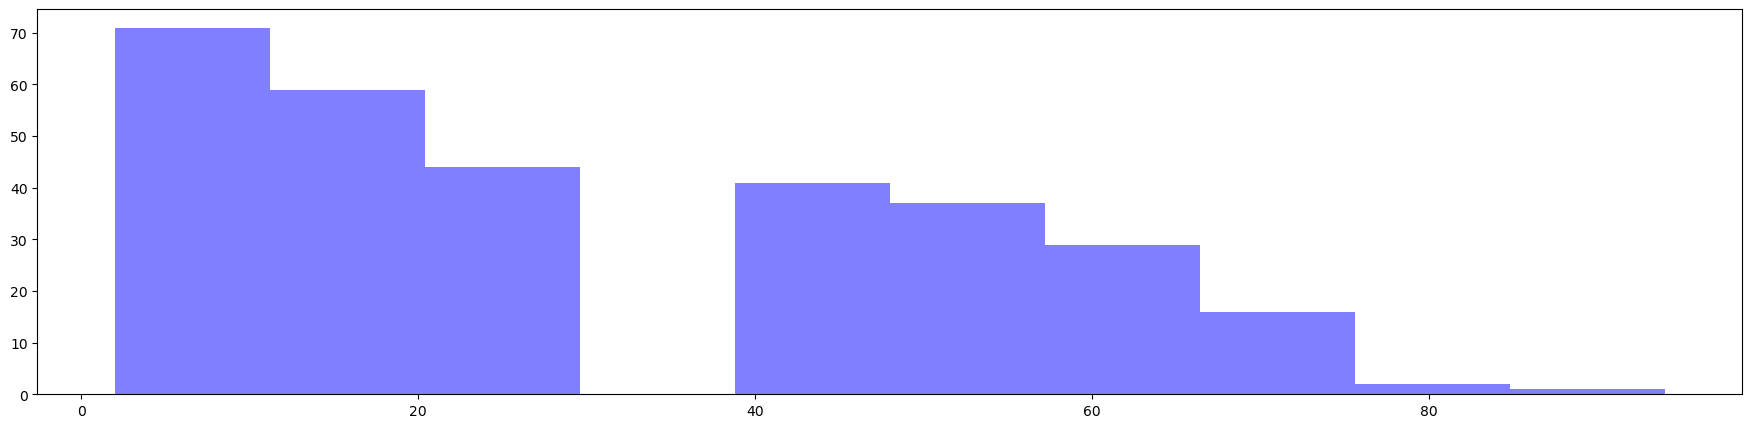

In [15]:
import matplotlib.pyplot as plt
n, bins, patches = plt.hist([len(s['requests']) for s in sessions], facecolor='blue', alpha=0.5)
plt.rcParams["figure.figsize"] = (22,5)
plt.show()

In [16]:
from collections import OrderedDict
def get_unique_urls(sessions):
    urls = OrderedDict()
    index = 0
    for s in sessions:
        for r in s['requests']:
            url = r['url']
            if url not in urls:
                urls[url] = index
                index += 1
        
    return urls

def get_unique_urls_extra(sessions, unique_urls):
    urls_extra = OrderedDict()
    index = 0
    for s in sessions:
        for r in s['requests']:
            url = r['url']
            if url not in urls_extra and url not in unique_urls:
                urls_extra[url] = index
                index += 1
        
    return urls_extra
    
unique_urls = get_unique_urls(sessions)
print(len(unique_urls))
print(list(unique_urls.items())[0])
extra_urls = get_unique_urls_extra([{'requests':[{'url': '12345'}]}], unique_urls)
print(extra_urls)                                  

200
('/wp-content/plugins/advanced-backgrounds/assets/awb/awb.min.css', 0)
OrderedDict([('12345', 0)])


In [17]:
unique_urls_vectors = urls_to_vec(list(unique_urls.keys()), host)
print('done.')

Tokenizing...
Embedding...
done.


In [18]:
a=unique_urls_vectors
b=unique_urls_vectors

In [23]:
a.shape[1]

128

In [20]:
tf.concat([a, b], 0).shape

TensorShape([400, 128])

In [17]:
def create_dataset(sessions, unique_urls, unique_urls_vectors, host):
    X = []
    y = []
    print('embedding extra urls...')
    urls_extra = get_unique_urls_extra(sessions, unique_urls)
    print(f'extra urls = {len(urls_extra)}')
    urls_extra_vectors = urls_to_vec(list(urls_extra.keys()), host)
    print('vectorizing urls...')
    for s in sessions:
        vector_average = []
        for r in s['requests']:
            url = r['url']
            if url in unique_urls:
                vector_average.append(unique_urls_vectors[unique_urls[url]])
            else:
                vector_average.append(urls_extra_vectors[urls_extra[url]])
        X.append(np.average(vector_average, axis=0))
    return np.array(X)

In [18]:
Y = create_dataset(sessions, unique_urls, unique_urls_vectors, host)
print('Done.')

embedding extra urls...
extra urls = 0
Tokenizing...
Embedding...
vectorizing urls...
Done.


In [19]:
Y.shape

(3000, 128)

In [20]:
Y_train, Y_test, _, _ = train_test_split(Y, Y, test_size=0.2, random_state=0)

In [21]:
def normalize(Y):
    Z = (Y - mean) / std
    Z[np.isnan(Z)] = 0
    return Z

In [22]:
mean = Y_train.mean(axis=0)
std = Y_train.std(axis=0)
print(f'Zero urls in training dataset: {std[std == 0].shape}')
std[std == 0] = 1
Z = normalize(Y_train)

Zero urls in training dataset: (0,)


In [25]:
total_pca_components = 100
target_explained_variance = 0.97
target_false_positive_rate = 0.03

In [26]:
from sklearn.decomposition import PCA
pca = PCA(n_components=total_pca_components)
print(
    f'Fitting PCA with {total_pca_components} components for {len(Z)} samples of size {Z.shape[1]}')
pca.fit(Z)

Fitting PCA with 100 components for 2400 samples of size 128


PCA(n_components=100)

In [27]:
explained_variance = pca.explained_variance_ratio_.cumsum()
num_components = total_pca_components
for i in range(len(explained_variance)):
    print(f'{i}, {explained_variance[i]}')
    if explained_variance[i] >= target_explained_variance:
        num_components = i
        break
print(f'Number of components = {num_components}')

0, 0.36862748861312866
1, 0.47403985261917114
2, 0.5492945313453674
3, 0.6129113435745239
4, 0.661324143409729
5, 0.6984485983848572
6, 0.7265551090240479
7, 0.7530757188796997
8, 0.775054931640625
9, 0.7940741777420044
10, 0.8113855123519897
11, 0.8274893760681152
12, 0.841235339641571
13, 0.8534834980964661
14, 0.8644620776176453
15, 0.874717116355896
16, 0.8845650553703308
17, 0.8929078578948975
18, 0.9006827473640442
19, 0.9081390500068665
20, 0.9142528772354126
21, 0.9198362827301025
22, 0.9252122640609741
23, 0.9302799701690674
24, 0.9346415996551514
25, 0.9388392567634583
26, 0.94263756275177
27, 0.9460769891738892
28, 0.9494921565055847
29, 0.9526856541633606
30, 0.9554598331451416
31, 0.9580497741699219
32, 0.9605947732925415
33, 0.9629146456718445
34, 0.9651487469673157
35, 0.9671570062637329
36, 0.9690368175506592
37, 0.9708460569381714
Number of components = 37


In [28]:
def _create_projector(components):
    PPT = np.dot(components, components.transpose())
    return np.identity(components.shape[0]) - PPT
    
def _score_vectors(Z):
    Ya = np.matmul(projector, Z.transpose())
    Z[np.isnan(Z)] = 0
    return (Ya ** 2).mean(axis=0)

In [29]:
components = pca.components_[:num_components, :].transpose()
projector = _create_projector(components)

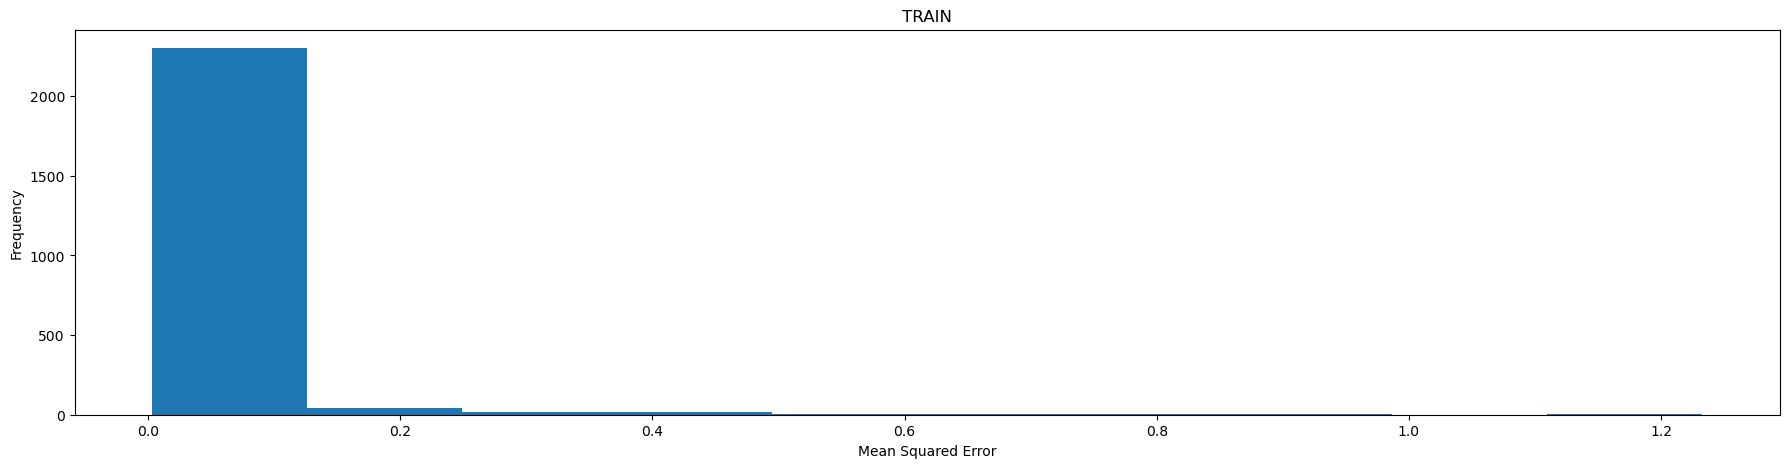

Threshold=0.299682392900344, false_positive_rate=0.02


In [32]:
score_train = _score_vectors(Z)
plt.hist(score_train)
plt.title('TRAIN')
plt.xlabel('Mean Squared Error')
plt.ylabel('Frequency')
plt.show()
threshold = np.percentile(score_train, 98)
FPR = len(score_train[score_train>threshold])/len(score_train)
print(f'Threshold={threshold}, false_positive_rate={FPR}')


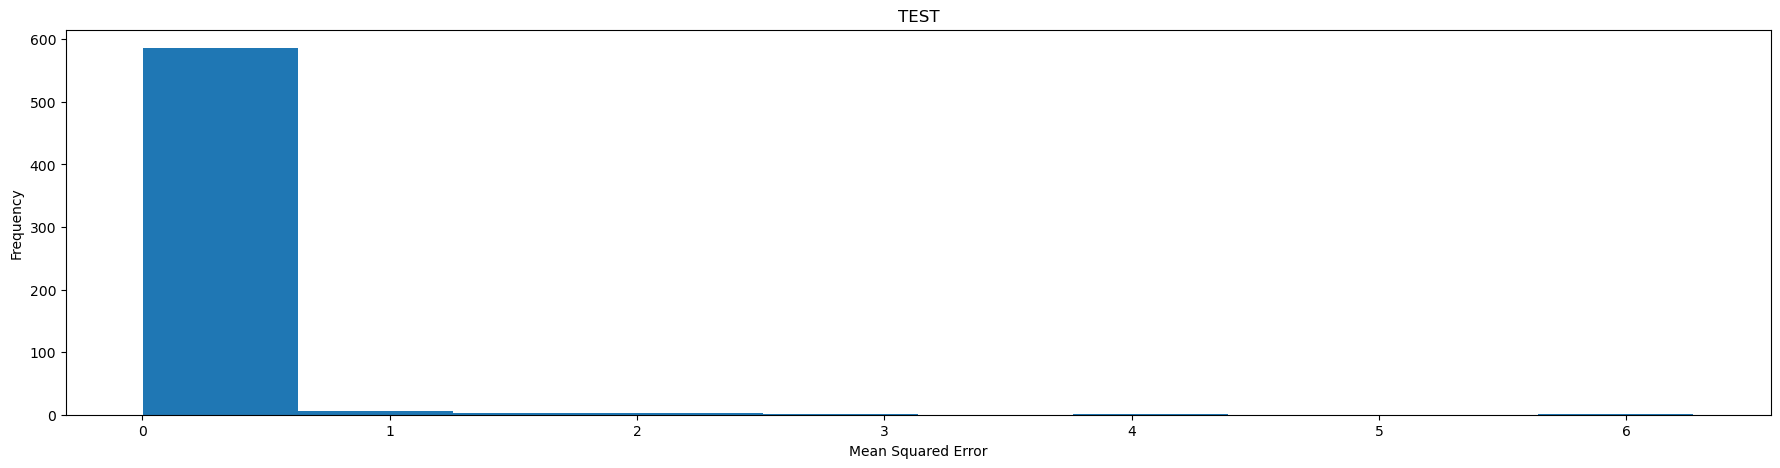

Threshold=0.299682392900344, false_positive_rate=0.035


In [33]:
Z_test = normalize(Y_test)
score_test = _score_vectors(Z_test)
plt.hist(score_test)
plt.title('TEST')
plt.xlabel('Mean Squared Error')
plt.ylabel('Frequency')
plt.show()
FPR = len(score_test[score_test>threshold])/len(score_test)
print(f'Threshold={threshold}, false_positive_rate={FPR}')

In [37]:
def score(sessions, host):
    Y = create_dataset(sessions, unique_urls, unique_urls_vectors, host)
    return _score_vectors(normalize(Y))

## Home page

In [66]:
duration = 60
hit_rate = 7
session = {'duration': duration, 'fresh_sessions': False, 'session_id':'-'}
requests = []
num_hits = int(duration * hit_rate / 60)
ts = datetime.now()
time_increment = 60.0 / hit_rate
print(f'Num hits = {num_hits}, duration = {duration} s')
for i in range(num_hits):
    requests.append({'ts': ts, 
                     # 'url': '/', 
                     # 'url': f'fs{i}',
                     'url': sessions[0]['requests'][0]['url'],
                     # 'url': '/wp-content/uploads/2216/26/thumbnail_harry-maria-768x344.jpg',
                     'query': '', 'code': 200, 'type': 'text/html','payload': 1000})
    ts += timedelta(seconds=time_increment)

requests.append(sessions[0]['requests'][1])
session['requests'] = requests
scores = score(
    [session], 
    # [sessions[0]], 
    host)

print(f'timer = {(datetime.now()-ts).total_seconds()}')
print(f'Threshold={threshold}')
print(f"Score: {scores[0]}")
print(f'Prediction={scores[0] > threshold}')

Num hits = 7, duration = 60 s
embedding extra urls...
extra urls = 0
Tokenizing...
Embedding...
vectorizing urls...
timer = -59.993221
Threshold=0.299682392900344
Score: 0.2767478309970527
Prediction=False


In [62]:
session

{'duration': 60,
 'fresh_sessions': False,
 'session_id': '-',
 'requests': [{'ts': datetime.datetime(2024, 6, 25, 17, 46, 1, 576737),
   'url': '/wp-content/uploads/2216/25/thumbnail_harry-sara-768x344.jpg',
   'query': '',
   'code': 200,
   'type': 'text/html',
   'payload': 1000},
  {'ts': datetime.datetime(2024, 6, 25, 17, 46, 31, 576737),
   'url': '/wp-content/uploads/2216/25/thumbnail_harry-sara-768x344.jpg',
   'query': '',
   'code': 200,
   'type': 'text/html',
   'payload': 1000}]}

## Bots Sessions

In [52]:
sessions2, ips = read_sessions(
    host = host,
    max_size=500,
    human=False,
    datetime_format=datetime_format
)

scores2 = score(sessions2, host)
FPR = len(scores2[scores2>threshold])/len(scores2)
print(f'Threshold={threshold}, false_positive_rate={FPR}')


Reading from kafka. Host = verafiles.org ... partition = 1
100 sessions read 2024-06-25 11:01:43 1719313453646
200 sessions read 2024-06-25 11:34:05 1719315400078
300 sessions read 2024-06-25 12:19:04 1719317946218
400 sessions read 2024-06-25 12:57:58 1719320384269
500 sessions read 2024-06-25 13:31:12 1719322338830
embedding extra urls...
extra urls = 371
Tokenizing...
Embedding...
vectorizing urls...
Threshold=0.299682392900344, false_positive_rate=0.882


In [54]:
sessions[0]['requests'][0]

{'ts': '2024-06-25 10:07:40',
 'url': '/wp-content/uploads/2216/25/thumbnail_harry-sara-768x344.jpg',
 'ua': 'Mozilla/5.0 (Linux; Android 10; K) AppleWebKit/537.36 (KHTML, like Gecko) SamsungBrowser/25.0 Chrome/121.0.0.0 Mobile Safari/537.36',
 'query': '',
 'code': 200,
 'type': 'image/jpeg',
 'payload': 38001,
 'method': 'GET',
 'edge': 'hetzner53.prod.deflect.network',
 'static': True,
 'banjax_decision': '-'}

## Another host FPR

Reading from kafka. Host = btselem.org ... partition = 0
100 sessions read 2024-04-14 04:53:25 1713070408957
200 sessions read 2024-04-14 07:14:45 1713078888310
300 sessions read 2024-04-14 09:28:40 1713086921389
400 sessions read 2024-04-14 12:00:24 1713096026905
500 sessions read 2024-04-14 15:04:02 1713107044518
embedding extra urls...
extra urls = 1586
Tokenizing...
Embedding...
vectorizing urls...
unwrapping...
16/16 [==============================] - 2s 129ms/step
FPR=0.196
0.040352489646574334
0.02425236749710888


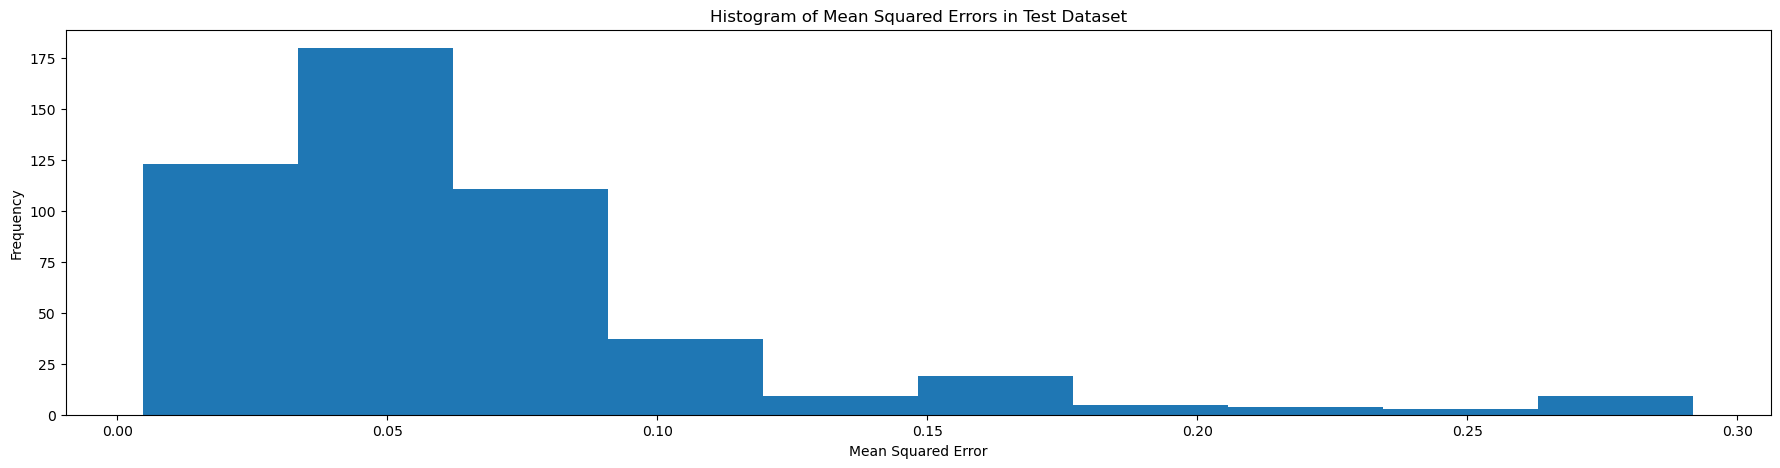

In [98]:
# host2 = 'zhitomir.info'
host2 = 'btselem.org'

sessions2, ips = read_sessions(
    host = host2,
    max_size=500,
    read_primary=True,
    datetime_format=datetime_format
)

X2, X2_delays = create_dataset(sessions2, unique_urls, unique_urls_vectors, datetime_format, host2, num_steps=num_steps)
predictions = model.predict([X2, X2_delays])
predictions_output_1, predictions_output_2 = predictions

error_1 = np.mean(np.square(predictions[0] - X2), axis=(1, 2))
error_2 = np.mean(np.abs(predictions[1] - X2_delays.reshape(predictions[1].shape)), axis=(1,2))
error = error_1 + error_2 #/predictions_output_1.shape[1]

print(f'FPR={len(error[error>threshold]) * 1.0 / len(error)}')
print(np.mean(error_1))
print(np.mean(error_2))
# Plotting the histogram of MSE values
plt.hist(error)
plt.title('Histogram of Mean Squared Errors in Test Dataset')
plt.xlabel('Mean Squared Error')
plt.ylabel('Frequency')
plt.show()

##  Verafile.org home page

In [101]:
session = {
    'duration': 8,
    'primary_session': False,
    'country': 'US',
    'requests': 
    [
        {'ts': '2024-04-10 14:58:14', 'url': '/wp-content/uploads/2024/04/Valor8-800x567.jpg', 'ua': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36', 'query': '', 'code': 304, 'type': '', 'payload': 0, 'method': 'GET'}, 
        {'ts': '2024-04-10 14:58:14', 'url': '/wp-content/uploads/2024/04/MOM-PH-2023-cover-image.jpg', 'ua': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36', 'query': '', 'code': 304, 'type': '', 'payload': 0, 'method': 'GET'}, 
        {'ts': '2024-04-10 14:58:26', 'url': '/specials/fact-check-filipino', 'ua': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 34202, 'method': 'GET'},
        {'ts': '2024-04-10 14:58:32', 'url': '/specials/fact-check-filipino', 'ua': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 34202, 'method': 'GET'},
        {'ts': '2024-04-10 14:58:48', 'url': '/specials/fact-check-filipino', 'ua': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 34202, 'method': 'GET'}
    ]
}

X2, X2_delays = create_dataset(
    # [session], 
    [sessions[90]],
    unique_urls, unique_urls_vectors, datetime_format, host, num_steps=num_steps)
predictions = model.predict([X2, X2_delays])
error_1 = np.mean(np.square(predictions[0] - X2), axis=(1, 2))
error_2 = np.mean(np.abs(predictions[1] - X2_delays.reshape(predictions[1].shape)), axis=(1,2))
error = error_1 + error_2

print(f'errorTotal_home={error}, \nerror1_home={error_1}, \nerror2_home={error_2}')
print(f'timer = {(datetime.now()-ts).total_seconds()}')
print(f'Threshold={threshold}')
print(f"Root MSE: {error}")
print(f'Prediction={error > threshold}')

embedding extra urls...
extra urls = 0
Tokenizing...
Embedding...
vectorizing urls...
unwrapping...
1/1 [==============================] - 0s 113ms/step
errorTotal_home=[0.00409086], 
error1_home=[0.00230048], 
error2_home=[0.00179039]
timer = 99.078155
Threshold=0.08208709637511047
Root MSE: [0.00409086]
Prediction=[False]


In [100]:
error.shape

2024-04-10 14:58:14 /wp-content/uploads/2024/04/Valor8-800x567.jpg
2024-04-10 14:58:14 /wp-content/uploads/2024/04/MOM-PH-2023-cover-image.jpg
2024-04-10 14:58:26 /specials/fact-check-filipino


## Home page

In [96]:
duration = 60
hit_rate = 50
country = 'US'
session = {'duration': duration, 'country': country, 'fresh_sessions': False, 'session_id':'-'}
requests = []
num_hits = int(duration * hit_rate / 60)
ts = datetime.now()
time_increment = 60.0 / hit_rate
countries = []
print(f'Num hits = {num_hits}, duration = {duration} s')
for i in range(num_hits):
    requests.append({'ts': ts, 
                     'url': '/', 
                     # 'url': f'fs{i}',
                     # 'url': sessions[0]['requests'][0]['url'],
                     'query': '', 'code': 200, 'type': 'text/html','payload': 1000})
    ts += timedelta(seconds=time_increment)
    countries.append(country)
session['requests'] = requests
X2, X2_delays = create_dataset(
    [session], 
    # [sessions[90]],
    unique_urls, unique_urls_vectors, datetime_format, host, num_steps=num_steps)
predictions = model.predict([X2, X2_delays])
error_1 = np.mean(np.square(predictions[0] - X2), axis=(1, 2))
error_2 = np.mean(np.abs(predictions[1] - X2_delays.reshape(predictions[1].shape)), axis=(1,2))
error = error_1 + error_2

print(f'errorTotal_home={error}, \nerror1_home={error_1}, \nerror2_home={error_2}')
print(f'timer = {(datetime.now()-ts).total_seconds()}')
print(f'Threshold={threshold}')
print(f"Root MSE: {error}")
print(f'Prediction={error > threshold}')

Num hits = 50, duration = 60 s
embedding extra urls...
extra urls = 0
Tokenizing...
Embedding...
vectorizing urls...
unwrapping...
1/1 [==============================] - 0s 105ms/step
errorTotal_home=[0.08047926], 
error1_home=[0.04466339], 
error2_home=[0.03581586]
timer = -59.809271
Threshold=0.08208709637511047
Root MSE: [0.08047926]
Prediction=[False]


In [42]:
for i in range(len(sessions)):
    s = sessions[i]
    if len(s['requests']) < num_steps + 3:
        continue
    _, X2, X2_delays, y2, y2_delays = create_dataset(
        [s], 
        datetime_format, num_steps=num_steps)
    if X2.shape[0] == 0:
        continue    
    print(len(s['requests']), i)
    predictions = model.predict([X2, X2_delays])
    predictions_output_1, predictions_output_2 = predictions
    
    error1 = np.mean(np.square(y2 - predictions_output_1), axis=1)
    error2 = np.mean(np.square(y2_delays - predictions_output_2[:,0]), axis=0)
    errorTotal = error1 + error2 #/predictions_output_1.shape[1]
    error = np.mean(errorTotal, axis=0)
    print(f"Root MSE: {error}")
    if error > threshold:
        print(session)
        break
    


Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Em

KeyboardInterrupt: 

In [93]:
y2_delays

array([0.0078125, 0.0078125, 0.       , 0.015625 , 0.1171875, 0.       ,
       0.0390625, 0.0703125, 0.0078125, 0.09375  , 0.015625 , 0.0078125,
       0.       , 0.03125  , 0.0078125, 0.       , 0.0859375, 0.1171875,
       0.015625 , 0.09375  , 0.03125  , 0.       , 0.0390625, 0.       ,
       0.0078125, 0.0078125, 0.       , 0.       , 0.0078125, 0.       ,
       0.0234375, 0.0078125, 0.0234375, 0.0703125, 0.015625 , 0.0390625,
       0.015625 , 0.046875 , 0.0234375, 0.015625 , 0.0078125, 0.046875 ,
       0.03125  , 0.0625   , 0.       , 0.015625 , 0.       , 0.0078125,
       0.0078125, 0.       , 0.0078125, 0.       , 0.       , 0.0078125,
       0.       , 0.015625 , 0.       , 0.0078125, 0.015625 , 0.03125  ,
       0.015625 , 0.0078125])

In [94]:
predictions_output_2

array([[-4.63646986e-02],
       [ 1.21090282e-02],
       [-3.59968208e-02],
       [-7.84119405e-03],
       [ 1.17962159e-01],
       [-3.75985689e-02],
       [ 2.53817644e-02],
       [ 1.85257178e-02],
       [-5.18511496e-02],
       [ 8.47426206e-02],
       [ 2.42508035e-02],
       [-4.36094441e-02],
       [-2.54838411e-02],
       [ 1.80113390e-02],
       [-8.21910519e-03],
       [-1.89214870e-02],
       [ 6.66479021e-02],
       [ 8.53596777e-02],
       [ 1.48325302e-02],
       [ 9.75755751e-02],
       [ 1.63974036e-02],
       [-2.59891804e-02],
       [ 2.38322280e-02],
       [-2.03898791e-02],
       [ 5.53515134e-03],
       [-2.02414189e-02],
       [-5.04366448e-03],
       [ 1.93972106e-03],
       [ 2.25331518e-04],
       [-6.96487306e-03],
       [ 8.17924389e-04],
       [ 1.00499075e-02],
       [ 1.22885583e-02],
       [ 3.83698642e-02],
       [ 3.64392623e-03],
       [ 1.75508484e-02],
       [ 1.95696503e-02],
       [ 4.43078838e-02],
       [-2.0

In [87]:
y2_delays

array([0.04261363])

In [88]:
predictions_output_2

array([[-0.05952261]], dtype=float32)

In [211]:
y2_delays - predictions_output_2[:,0]

array([-12.55694771,   0.56258678,   0.56258678,   0.56258678,
         0.56258678,   0.56258678])

In [53]:
predictions = model.predict(X2)
mse_values = np.mean(np.square(predictions - y2), axis=1)

1/1 [==============================] - 0s 30ms/step


In [54]:
mse_values

array([0.01957172, 0.00483445, 0.00483445, 0.00483445, 0.00483445,
       0.00483445, 0.00483445, 0.00483445, 0.00483445, 0.00483445,
       0.00483444, 0.00483444], dtype=float32)

In [67]:
num_home = 0
for s in sessions:
    for r in s['requests']:
        if r['url'] == '/':
            num_home += 1
            print('\n\n ###')
            for r in s['requests']:
                print(r['url'], r['ts'])
print(num_home, num_home * 100.0/len(sessions))



 ###
/articles/vera-files-fact-check-katwiran-ng-palasyo-sa-hindi-pagsama-ng-anibersaryo-ng-people-power-bilang-holiday-nakaliligaw 2024-03-08 04:42:35
/wp-content/uploads/2011/05/liwawa.png 2024-03-08 04:42:35
/articles/vera-files-fact-check-china-did-not-declare-war-vs-philippines 2024-03-08 04:42:40
/articles/vera-files-fact-check-romualdez-misleads-with-claim-that-price-ceiling-on-rice-set-by-marcos-has-affected-world-market 2024-03-08 04:42:53
/articles/vera-files-fact-check-p100-wage-hike-bill-not-yet-law 2024-03-08 04:42:55
/wp-content/uploads/2024/02/022224-FALSE-P100-wage-hike-passed_WEB_ENG.jpg 2024-03-08 04:42:56
/articles/vera-files-fact-check-hindi-inutos-ni-marcos-na-sibakin-ipakulong-o-paalisin-sa-pinas-si-sen-robin 2024-03-08 04:43:04
/wp-content/uploads/2023/10/vffc-confidential-funds-120x120.jpg 2024-03-08 04:43:41
/articles/vera-files-fact-sheet-bakit-kailangan-ang-confidential-at-intelligence-funds 2024-03-08 04:43:41
/articles/violin-prodigy-is-juilliard-bound 20

In [94]:

# Predict the next value (two-dimensional vector)
next_vector = model.predict(X[-num_steps:])[0]
print(f"Predicted next vector: {next_vector}")

1/1 [==============================] - 0s 26ms/step
Predicted next vector: [ 0.07221214  0.21693999  0.0784342   0.02563586  0.01143848 -0.18851225
  0.00611085  0.06646264 -0.1842081   0.09987619  0.04800044 -0.08932969
  0.1495375   0.15877268 -0.16429386  0.07818806  0.02932158  0.22956209
 -0.08299863 -0.11680726 -0.04841654  0.20351145 -0.14615172  0.05819415
 -0.08108544 -0.25210527 -0.24348718  0.27957487  0.15510416 -0.12804295
 -0.01280112 -0.12317632  0.14704691 -0.08027183 -0.22006027 -0.12634699
 -0.02456348 -0.12193092  0.08169118  0.1151506   0.0816001  -0.06002513
  0.3089745  -0.04447167 -0.09063466  0.16466685 -0.04610489 -0.07550969
 -0.00437683  0.0568261   0.05710223 -0.06307752  0.01604434  0.01055181
  0.16776983  0.3716555   0.21914153 -0.08170818 -0.00206302  0.10620315
 -0.07822333  0.07009785  0.01712641 -0.13944215  0.09832448 -0.08370674
  0.00940936 -0.12211141  0.03378075  0.16626726 -0.04200068  0.22686541
 -0.04942314 -0.11571244 -0.21995898 -0.21605985 

In [93]:
X[-num_steps:].shape

(2, 2, 300)

In [71]:
y.shape

(64, 300)

In [48]:
session_vectors = session_to_vec(
    sessions[0], 
    warmup_period=3, 
    datetime_format=datetime_format,
    model_embeddings=model_embeddings
)

In [55]:
for session in sessions:

SyntaxError: incomplete input (745880440.py, line 1)

In [51]:
session_vectors_to_samples(session_vectors, 1)

([[array([-3.43802311e-02,  7.93091953e-02,  5.75114675e-02,  9.45826918e-02,
          -1.12461634e-01, -9.28737074e-02, -9.30698961e-02, -2.08312988e-01,
           1.31081715e-01,  2.51922607e-02,  3.60717773e-02, -5.61152846e-02,
          -2.67181396e-02, -3.53480726e-02, -1.46885455e-01,  8.16301629e-02,
           8.92377570e-02,  8.03397000e-02,  7.18296617e-02, -1.61612377e-01,
          -1.20082311e-01,  1.80332720e-01,  4.21883725e-02,  5.07812500e-02,
           8.11767578e-02, -1.61307231e-02, -3.65557000e-02,  7.95211792e-02,
           2.63366699e-02,  4.73458432e-02, -1.05555944e-01,  4.24630381e-03,
          -4.16913703e-02, -1.60086498e-01,  3.04957759e-03,  3.49295475e-02,
          -2.82767154e-02,  4.29861918e-02, -5.63441701e-02,  1.00620814e-01,
           1.68831959e-01, -3.71180959e-02,  1.81483686e-01,  9.10688117e-02,
           3.98646779e-02,  1.59563348e-02, -1.27463207e-01,  1.41601562e-02,
          -2.76227687e-02,  1.33283347e-01,  2.58440301e-02,  7.

In [31]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from sklearn.model_selection import train_test_split

def create_dataset(sequence, n_steps):
    X, y = [], []
    for i in range(len(sequence)):
        end_ix = i + n_steps
        if end_ix > len(sequence) - 1:
            break
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

# Generating a synthetic sequence of two-dimensional vectors
sequence = [[i, i] for i in range(100)]  # Replace with your sequence
n_steps = 5  # Number of time steps in the sequence

# Prepare the dataset
X, y = create_dataset(sequence, n_steps)

# Each input sample is a sequence of n_steps vectors, each with 2 dimensions
input_shape = (n_steps, 2)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Define the GRU model
model = Sequential([
    GRU(50, activation='relu', input_shape=input_shape),
    Dense(2)  # Output layer with 2 units for the two-dimensional vector
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Fit the model
model.fit(X_train, y_train, epochs=200, verbose=0)

# Evaluate the model
mse = model.evaluate(X_test, y_test, verbose=0)
print(f"Mean Squared Error: {mse}")

# Predict the next value (two-dimensional vector)
next_vector = model.predict(np.array([sequence[-n_steps:]]))[0]
print(f"Predicted next vector: {next_vector}")


Mean Squared Error: 0.0031195098999887705
1/1 [==============================] - 0s 199ms/step
Predicted next vector: [100.00126 100.01248]


In [80]:
X[-n_steps:].shape

(5, 2, 300)